In [1]:
#%config InlineBackend.figure_formats=['svg']
from os import listdir
import numpy as np

from ExistingAlgorithms.Plot import plot_1D, plot_traces

from AutoencoderAPI.utils.files import load_mean_std
from AutoencoderAPI.utils.compare import compare
from AutoencoderAPI.utils.clustering.kernelDensity import kernel_density
from AutoencoderAPI.utils.clustering.densityGaussianMixture import density_gaussianMixture
from AutoencoderAPI.loadAutoencoder import loadAutoencoder

from ExistingAlgorithms.MaxValue import max_value
from ExistingAlgorithms.Area import area
from ExistingAlgorithms.SklearnAvailable import dimension_reduction

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE

In [2]:
signal_size = 30_000
certain_clusters = 3
path_test = 'Datasets/SNSPD/Paderborn/data test/'
path_train = 'Datasets/SNSPD/Paderborn/data train/'
path_model = 'run-2024-01-20-16-16/fold 0'
path_save = 'MetricLog/Metric_SNSPD'
mean, std = load_mean_std(path_model)
print(mean, std)

X_test = -1 * np.concatenate([np.load(f"{path_test}{fileName}").reshape(-1,signal_size)[::15, 3250:4500] for fileName in listdir(path_test)])#[::2]
X_train = -1 * np.concatenate([np.load(f"{path_train}{fileName}").reshape(-1,signal_size)[::15, 3250:4500] for fileName in listdir(path_train)])

X_test = (X_test - mean) / std
X_train = (X_train - mean) / std

#init_len = len(X_test)
#X_test = X_test[np.min(X_test, axis=1) < -0.5]
X_train = X_train[np.max(X_train, axis=1) > 0]
X_test = X_test[np.max(X_test, axis=1) > 0]
X_train = X_train[np.min(X_train, axis=1) < -1.6]
X_test = X_test[np.min(X_test, axis=1) <  -1.6]
#zeros = init_len - len(X_test)

9863.206395786667 17105.12738626451


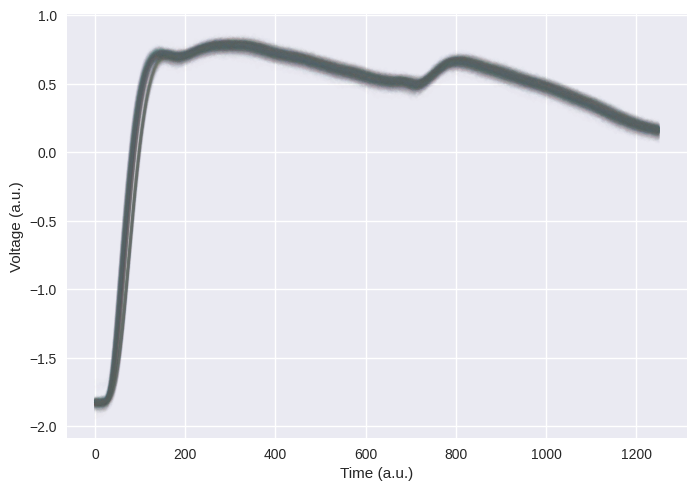

In [3]:
plot_traces(np.copy(X_test))

### Max Value

In [4]:
X_i_MAX, X_r_MAX, X_l_MAX = max_value(np.copy(X_test), filter=True)

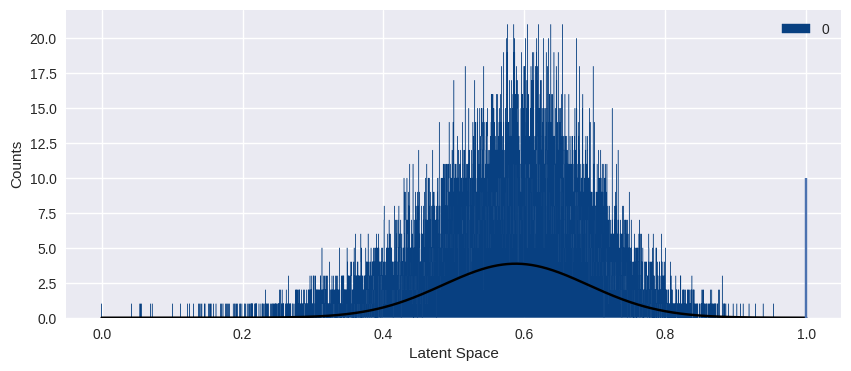

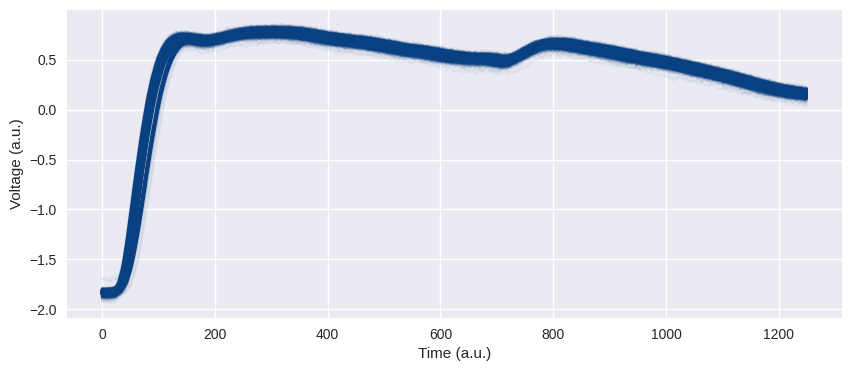

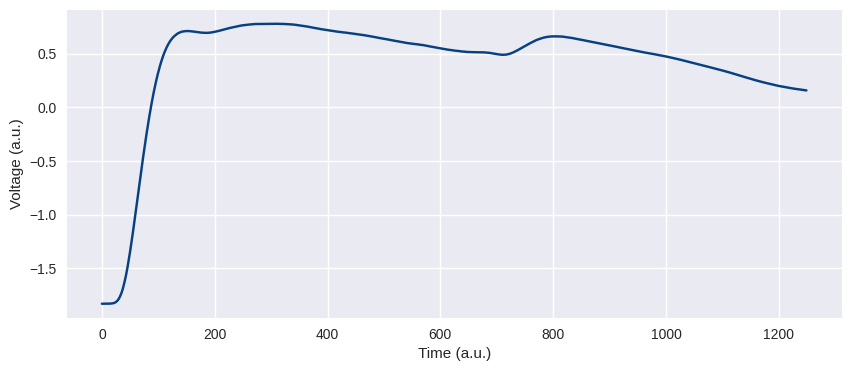

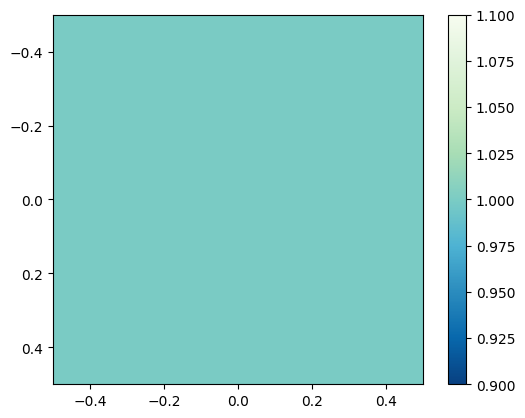

In [5]:
kd = density_gaussianMixture(X_l_MAX, 
                            bw = [0.02], 
                            min_cluster_prob = 0.1,
                            bins_plot = 5000,
                            flip = False, 
                            skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()
X_l_MAX = kd.normalize_latent(X_l_MAX, certain_clusters)

### Area

In [6]:
X_i_AREA, X_r_AREA, X_l_AREA = area(np.copy(X_test), filter=True, threshold_cst=0)

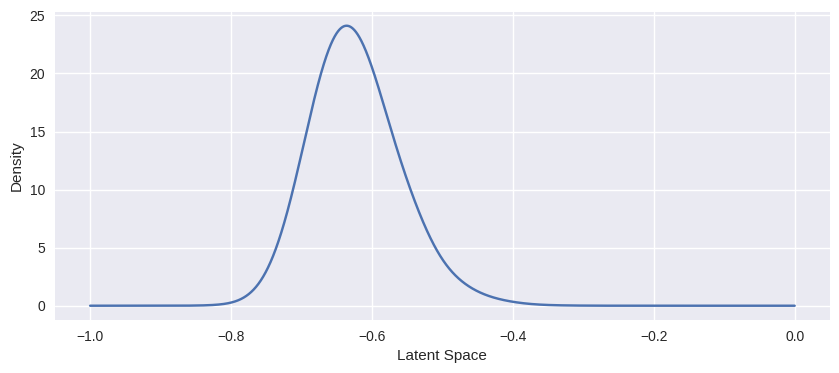

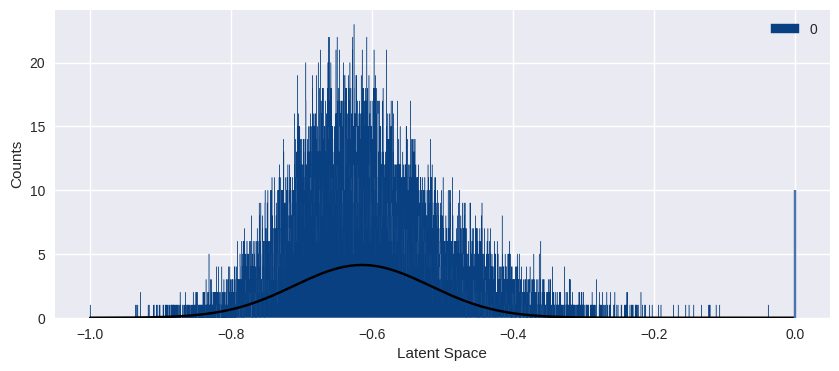

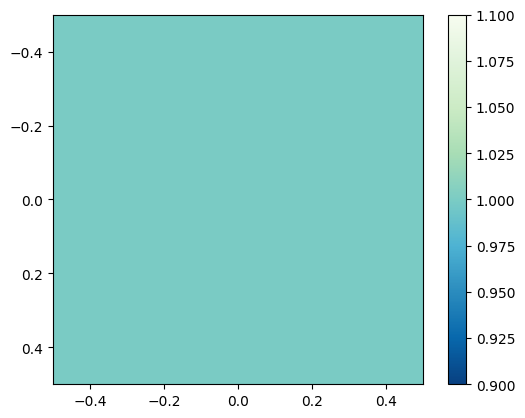

In [7]:
kd = density_gaussianMixture(X_l_AREA, 
                                bw = [0.0268], 
                                min_cluster_prob = 0.1,
                                bins_plot = 5000,
                                flip = True, 
                                skip = 1)
kd.plot_density()
kd.plot_cluster()
#kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
X_l_AREA = kd.normalize_latent(X_l_AREA, certain_clusters)

### Principal Component Analysis (PCA)

In [8]:
X_i_PCA, X_l_PCA = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save, PCA, n_components=1) 

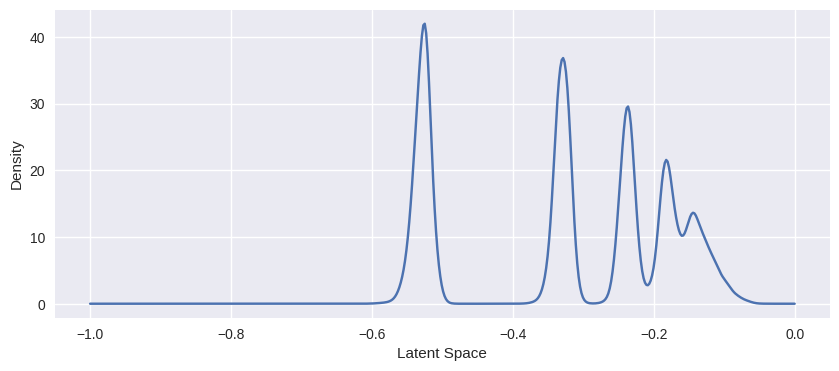

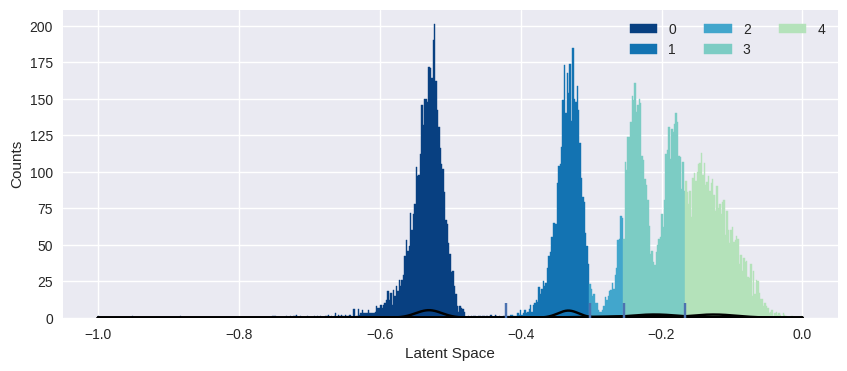

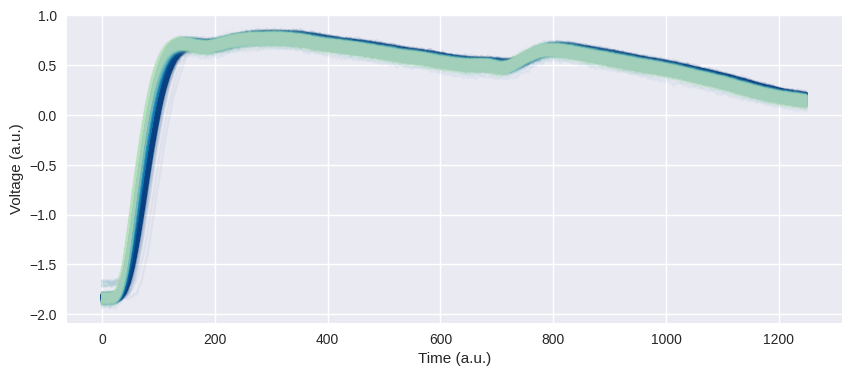

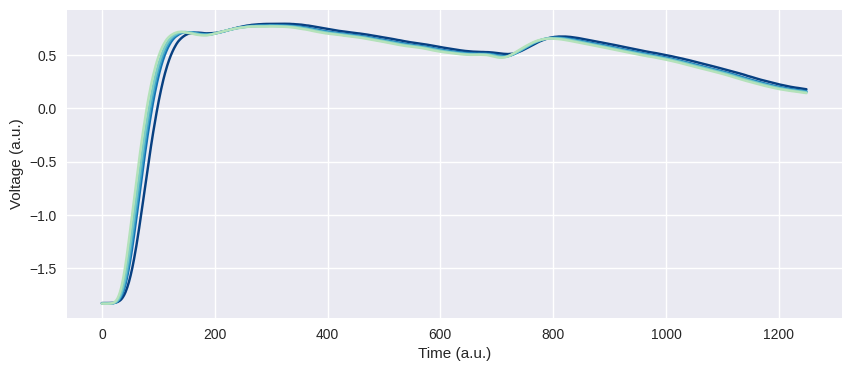

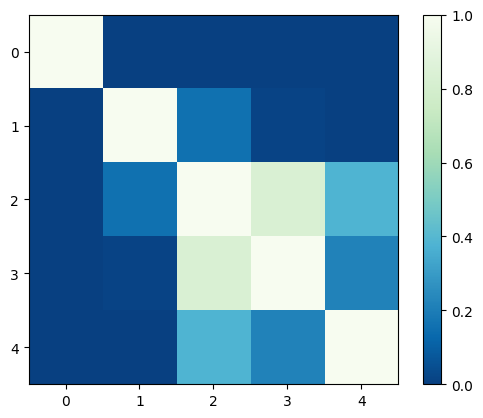

In [9]:
kd = density_gaussianMixture(X_l_PCA,
                            bw = [0.006],
                            min_cluster_prob = 0.08,
                            bins_plot = 500,
                            flip = True, 
                            skip = 0)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_PCA = kd.normalize_latent(X_l_PCA, certain_clusters)

### Kernel PCA (Polynomial)

In [10]:
X_i_KPCA_P, X_l_KPCA_P = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1, kernel="poly", fit_inverse_transform=True)

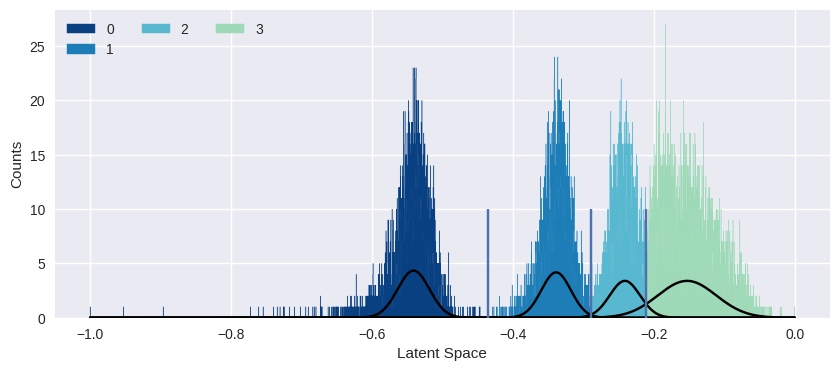

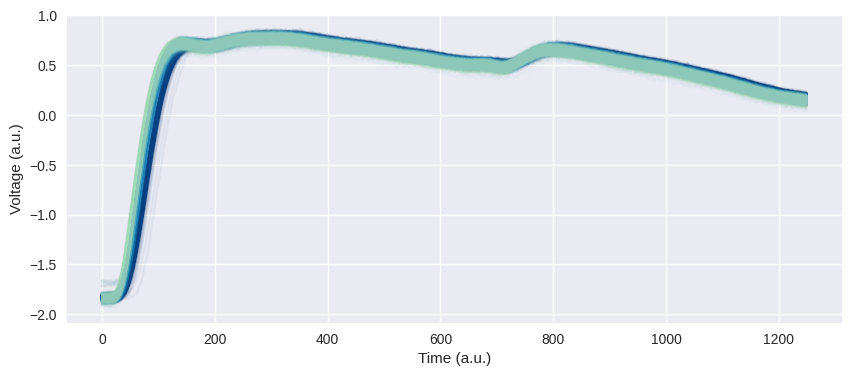

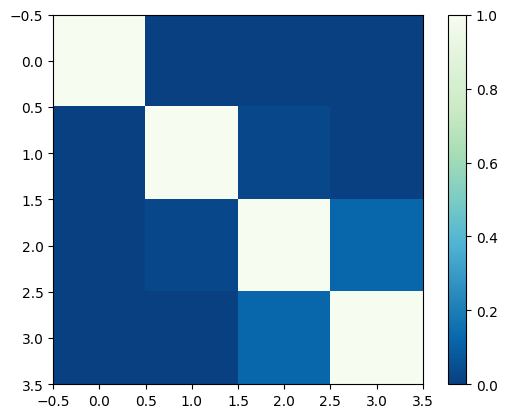

In [11]:
kd = density_gaussianMixture(X_l_KPCA_P, 
                                bw = [0.01], 
                                min_cluster_prob=0.05,
                                bins_plot = 5000,
                                flip = True, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_KPCA_P = kd.normalize_latent(X_l_KPCA_P, certain_clusters)

### Kernel PCA (Radial basis function)

In [12]:
X_i_KPCA_RBF, X_l_KPCA_RBF = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1,kernel="rbf",gamma=0.02, fit_inverse_transform=True)

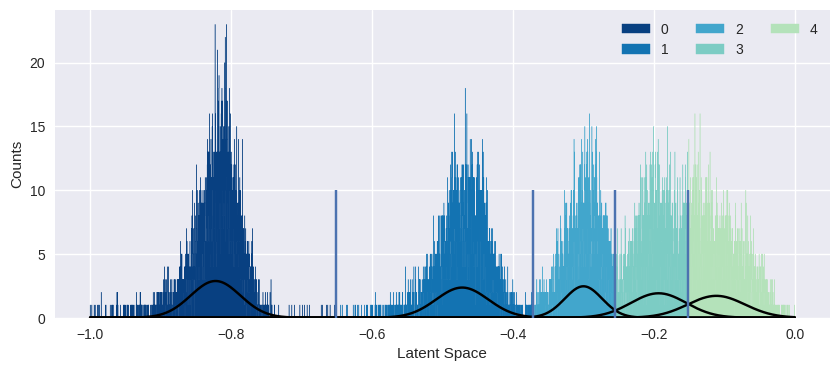

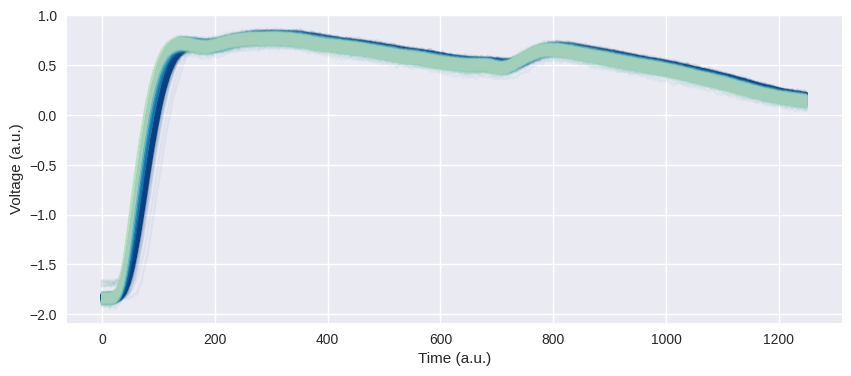

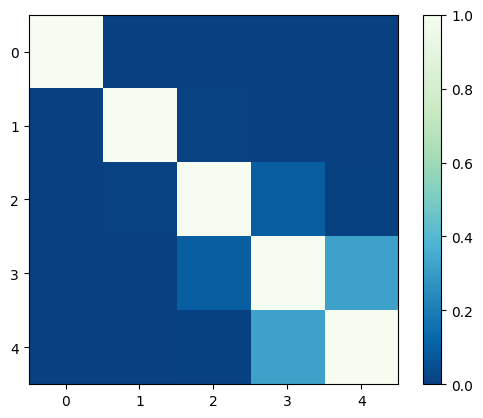

In [13]:
kd = density_gaussianMixture(X_l_KPCA_RBF, 
                                bw = [0.02], 
                                bins_plot = 5000,
                                flip = True, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_KPCA_RBF = kd.normalize_latent(X_l_KPCA_RBF, certain_clusters)

### Kernel PCA (Sigmoid)

In [14]:
X_i_KPCA_S, X_l_KPCA_S = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1,kernel="sigmoid",gamma=0.02, fit_inverse_transform=True)

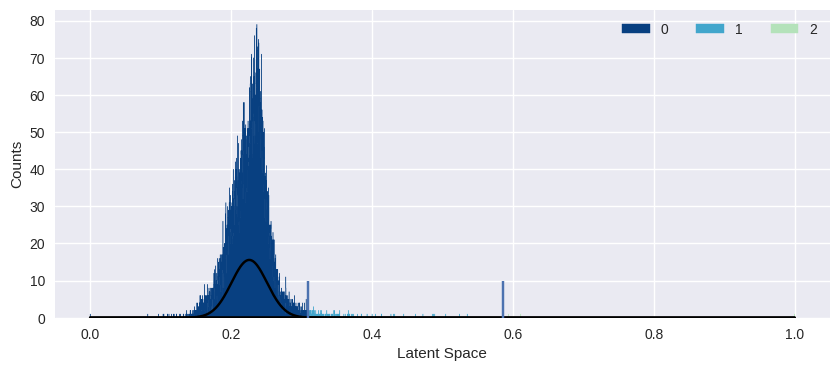

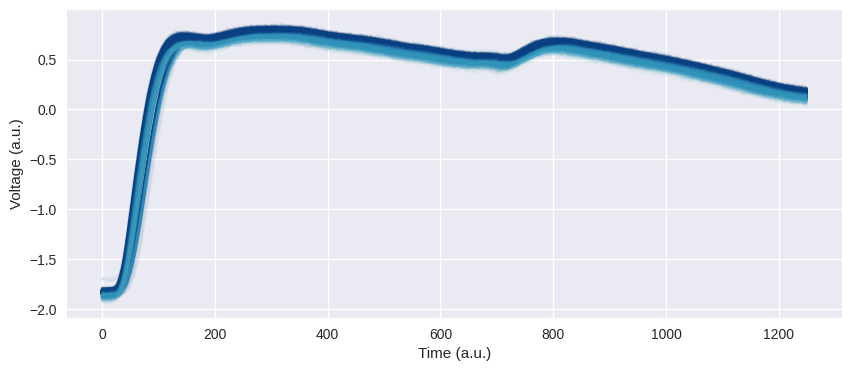

In [15]:
kd = density_gaussianMixture(X_l_KPCA_S, 
                                bw = [0.02], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
#kd.confidence(zeros)
X_l_KPCA_S = kd.normalize_latent(X_l_KPCA_S, certain_clusters)

### Kernel PCA (Cosine)

In [16]:
X_i_KPCA_C, X_l_KPCA_C = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,KernelPCA,n_components=1,kernel="cosine",gamma=0.02, fit_inverse_transform=True)

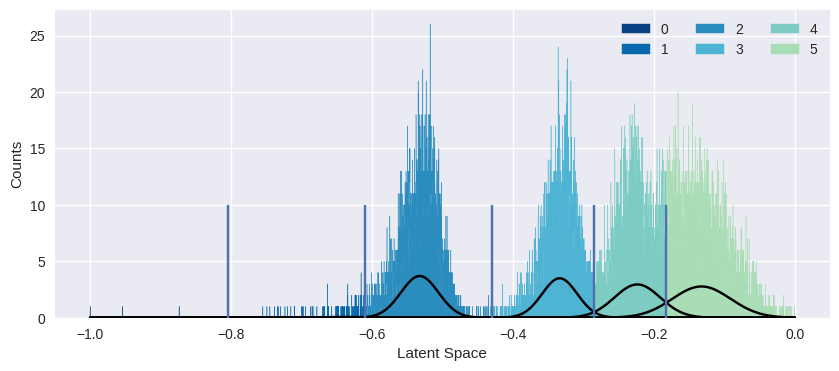

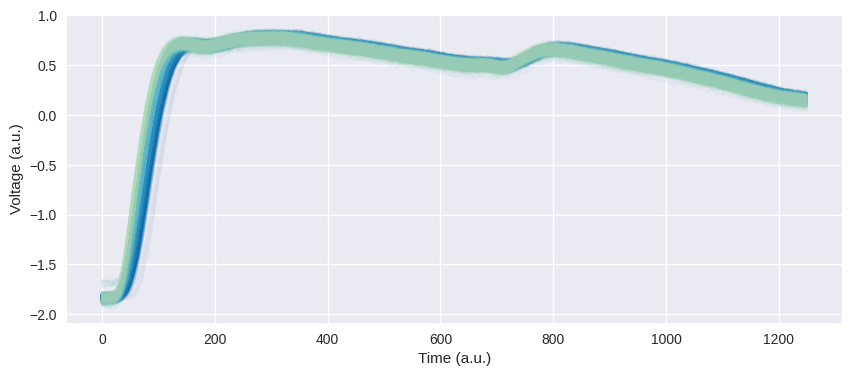

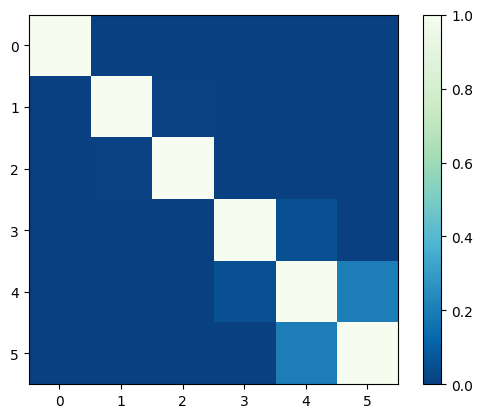

In [17]:
kd = density_gaussianMixture(X_l_KPCA_C, 
                                bw = [0.025], 
                                min_cluster_prob=0.05,
                                bins_plot = 5000,
                                flip = True, 
                                skip = 0)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_KPCA_C = kd.normalize_latent(X_l_KPCA_C, certain_clusters)

### t-distributed Stochastic Neighbor Embedding (t-SNE)

In [34]:
X_i_TSNE, X_l_TSNE = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save,TSNE,n_components=1, perplexity=2000)

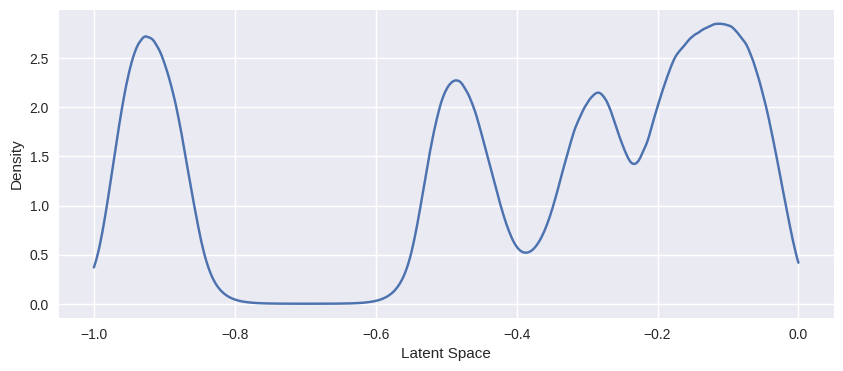

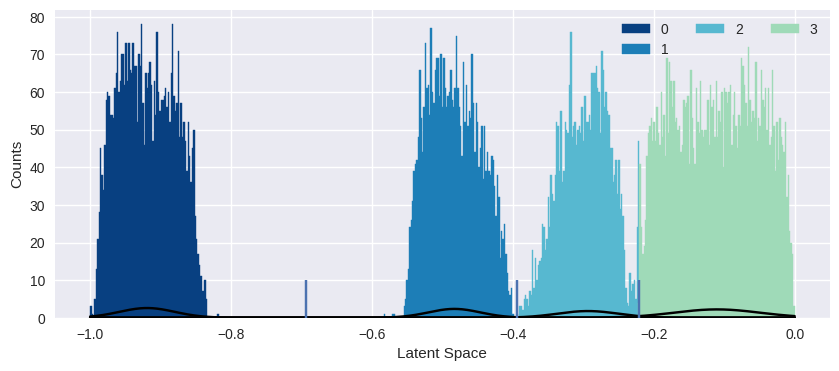

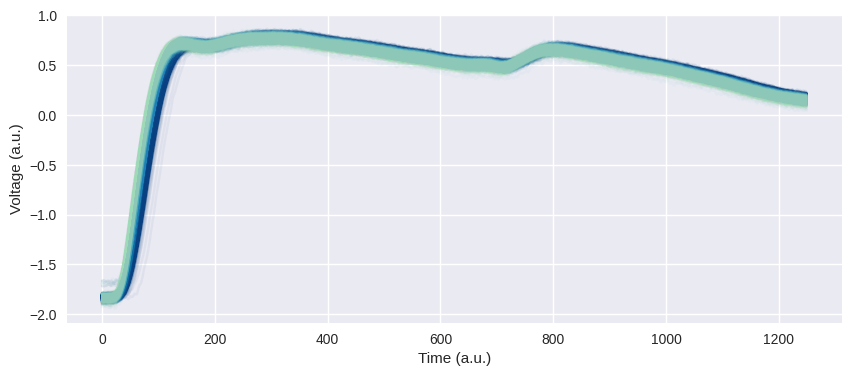

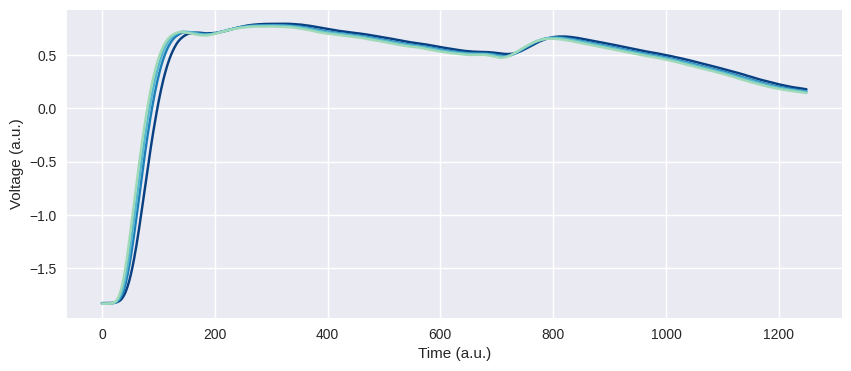

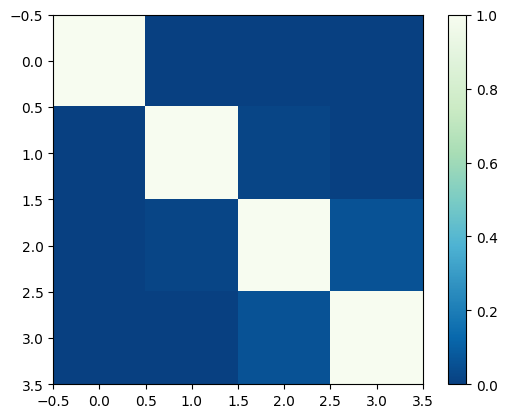

In [35]:
kd = density_gaussianMixture(X_l_TSNE,
                                bw = [0.04], 
                                density_kernel='exponential',
                                #min_cluster_prob=0.
                                bins_plot = 500,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()
#kd.confidence(zeros)
X_l_TSNE = kd.normalize_latent(X_l_TSNE, certain_clusters)

### Spectral Embedding 

In [20]:
#X_i_SE, X_r_SE, X_l_SE = dimension_reduction(np.copy(X),SpectralEmbedding,n_components=1)
#plot_1D(X_l_SE)

### Non-Negative Matrix Factorization (NMF)

In [21]:
X_i_NMF, X_l_NMF = dimension_reduction(2.1+np.copy(X_train),2.1+np.copy(X_test), path_save,NMF,n_components=1,alpha_W=0.1,random_state=42)

/home/nicolasdc/files/Single-Photon-Detection/src/AutoencoderAPI/utils/clustering/densityGaussianMixture.py:106: RuntimeWarning: invalid value encountered in sqrt
  mins[i] = (u2*sig1**2 - sig2*(u1*sig2 + sig1*np.sqrt((u1-u2)**2 + 2*(sig1**2-sig2**2)*np.log((sig1* coeff2) / (sig2* coeff1)))))/(sig1**2 - sig2**2)


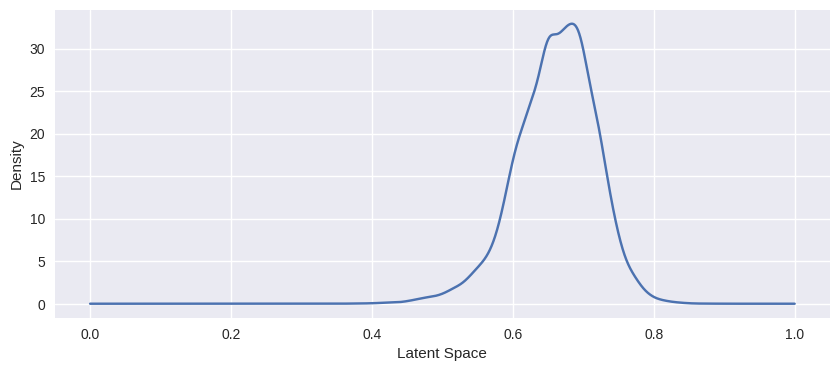

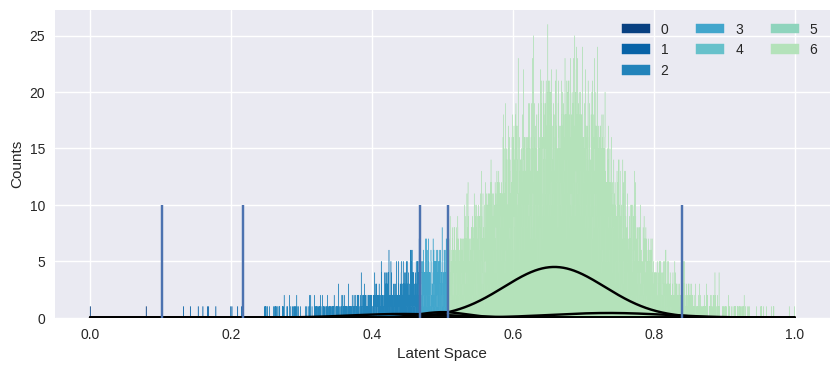

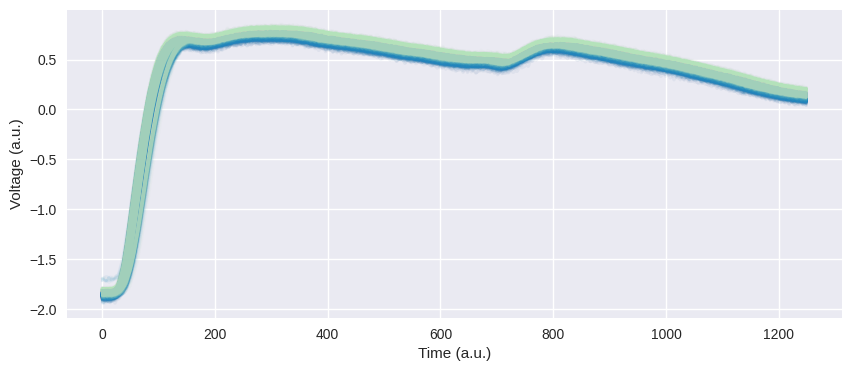

In [22]:
kd = density_gaussianMixture(X_l_NMF, 
                                bw = [0.01], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
X_l_NMF = kd.normalize_latent(X_l_NMF, certain_clusters)

### Isomap

In [23]:
X_i_ISO, X_l_ISO = dimension_reduction(np.copy(X_train),np.copy(X_test), path_save, Isomap,n_neighbors=10, n_components=1, eigen_solver="arpack")

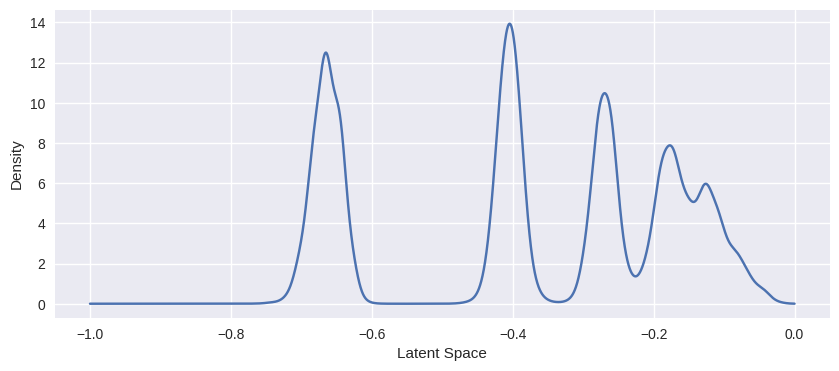

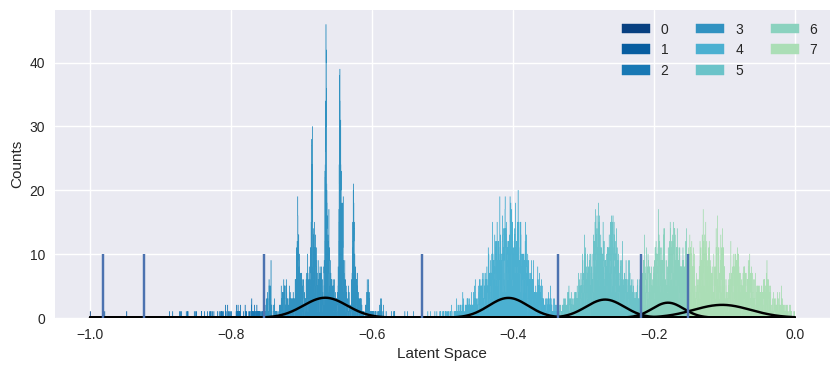

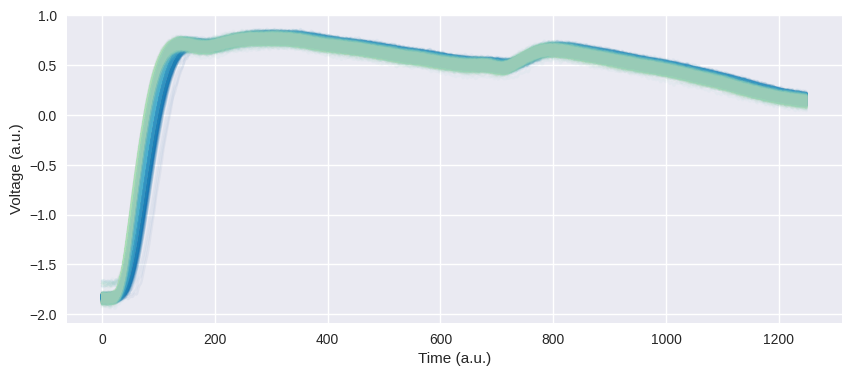

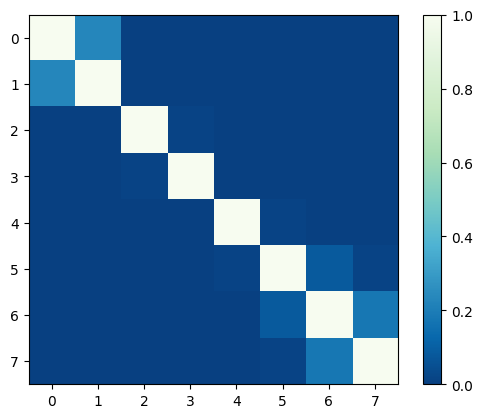

In [24]:
kd = density_gaussianMixture(X_l_ISO, 
                                bw = [0.01], 
                                bins_plot = 5000,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
X_l_ISO = kd.normalize_latent(X_l_ISO, certain_clusters)

### Autoencoder



In [25]:
X_i_AUTO, X_r_AUTO, X_l_AUTO  = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', filter=False, flip=True)

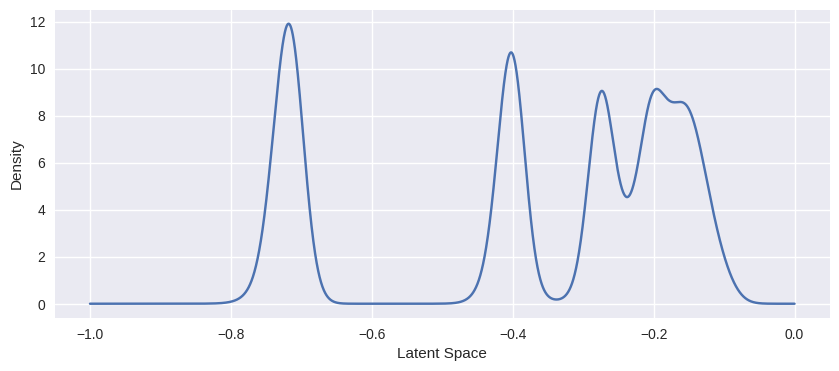

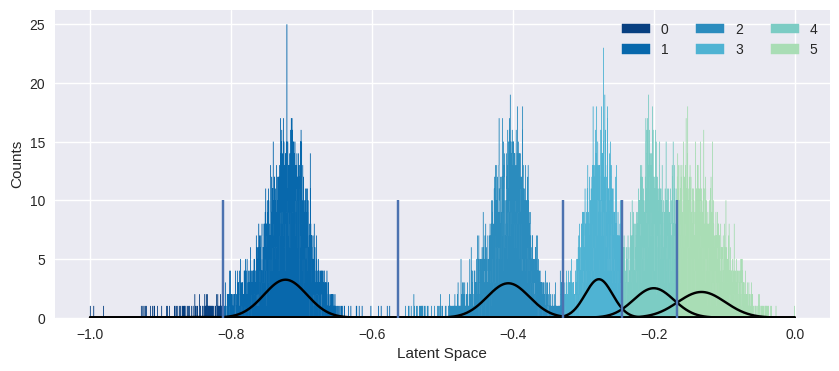

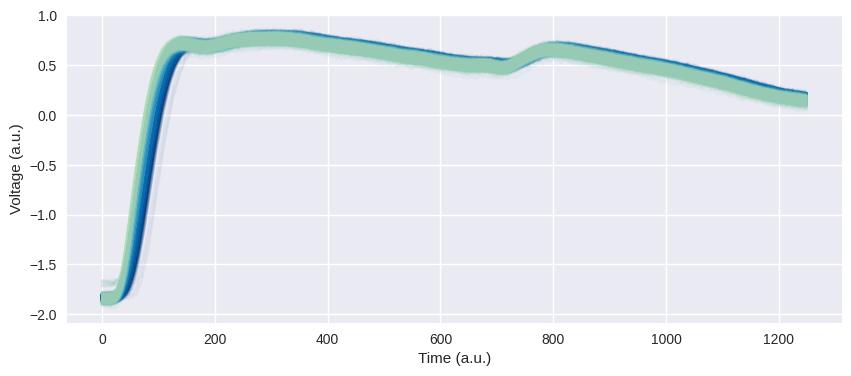

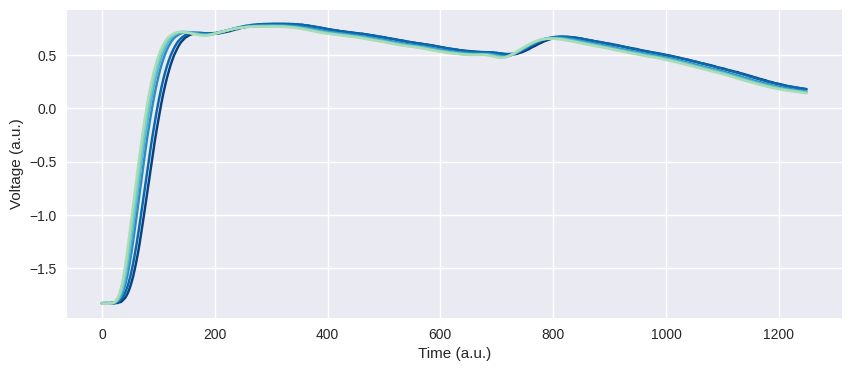

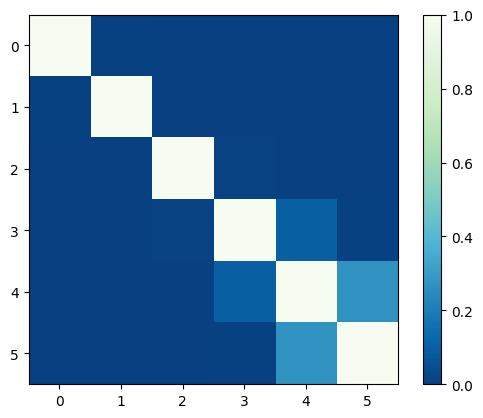

In [26]:
kd = density_gaussianMixture(X_l_AUTO, 
                                bw = [0.018], 
                                bins_plot = 5000,
                                flip = False, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))
kd.plot_traces_average(np.copy(X_test))
kd.plot_cross_talk()
X_l_AUTO = kd.normalize_latent(X_l_AUTO, certain_clusters)

In [27]:
X_i_AUTOF, X_r_AUTOF, X_l_AUTOF = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', 
                                                  filter=True, 
                                                  threshold=0.002)

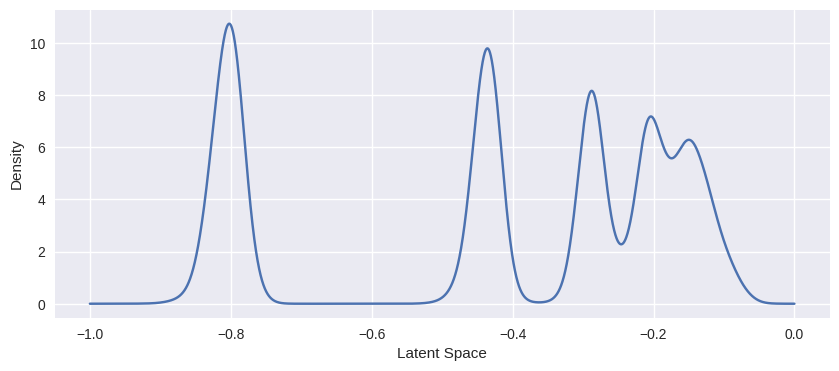

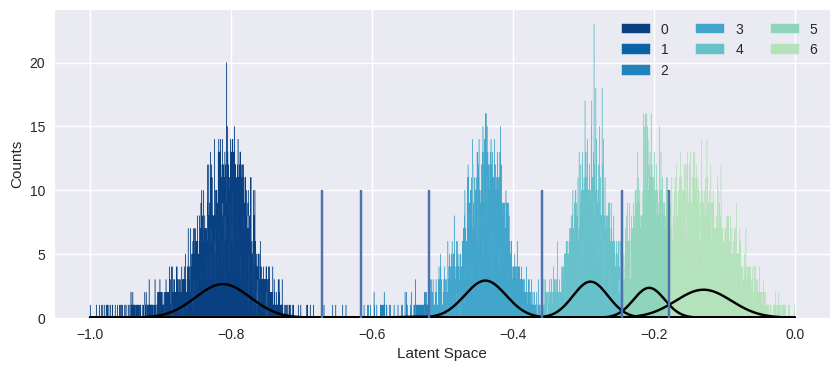

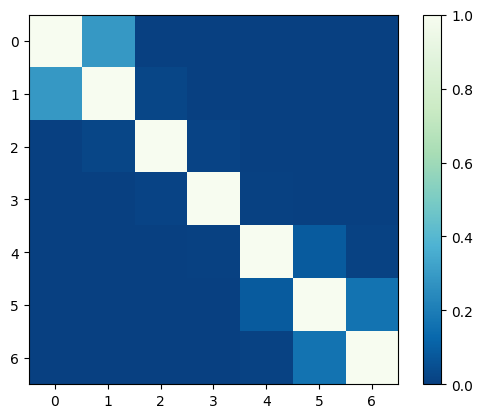

In [28]:
kd = density_gaussianMixture(X_l_AUTOF, 
                                bw = [0.015], 
                                bins_plot = 5000,
                                flip = True, 
                                skip = 0)
kd.plot_density()
kd.plot_cluster()
#kd.plot_traces(np.copy(X_test))
kd.plot_cross_talk()
X_l_AUTOF = kd.normalize_latent(X_l_AUTOF, certain_clusters)

In [29]:
i = [X_i_MAX, X_i_AREA, X_i_PCA, X_i_KPCA_P, 
     X_i_KPCA_RBF, X_i_KPCA_S, X_i_KPCA_C, #X_i_NMF, 
     X_i_TSNE, #X_i_ISO, 
      X_i_AUTO, X_i_AUTOF]
l = [X_l_MAX, X_l_AREA, X_l_PCA, X_l_KPCA_P, 
     X_l_KPCA_RBF, X_l_KPCA_S, X_l_KPCA_C, #X_l_NMF, 
     X_l_TSNE, #X_l_ISO, 
      X_l_AUTO, X_l_AUTOF]
#r = [X_r_MAX, X_r_AREA, X_r_PCA, X_r_KPCA_P, 
#     X_r_KPCA_RBF, X_r_KPCA_S, X_r_KPCA_C, #X_r_NMF,
#     X_r_TSNE, #X_r_ISO, 
#      X_r_AUTO, X_r_AUTOF]
methods = ['Max', 'Area', 'PCA', 'K-PCA (Polynomial)', 
           'K-PCA (RBF)', 'K-PCA (Sigmoid)', 
           'K-PCA (Cosine)', #'NMF', 
           't-SNE', #'Isomap',
           'Autoencoder', 'Autoencoder\nFiltered']
flip = [False, True, True, True, True, False, True, True, True, False]
bw = [0.02, 0.03, 0.013, 0.02,
      0.015, 0.02, 0.025, 0.032, 0.019, 0.015]

comp = compare(flip, bw)
comp.quality_metric_plot(i,l,methods, 10)

  0%|          | 0/10 [00:00<?, ?it/s]

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 727, in _fit_and_score
    estimator.fit(X_train, **fit_params)
  File "/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/sklearn/base.py", line 1145, in wrapper
    estimator._validate_params()
  File "/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/sklearn/base.py", line 638, in _validate_params
    validate_parameter_constraints(
  File "/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/sklearn/utils/_param_validation.py", line 96, in validate_parameter_constraints
    raise InvalidParameterErro